c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


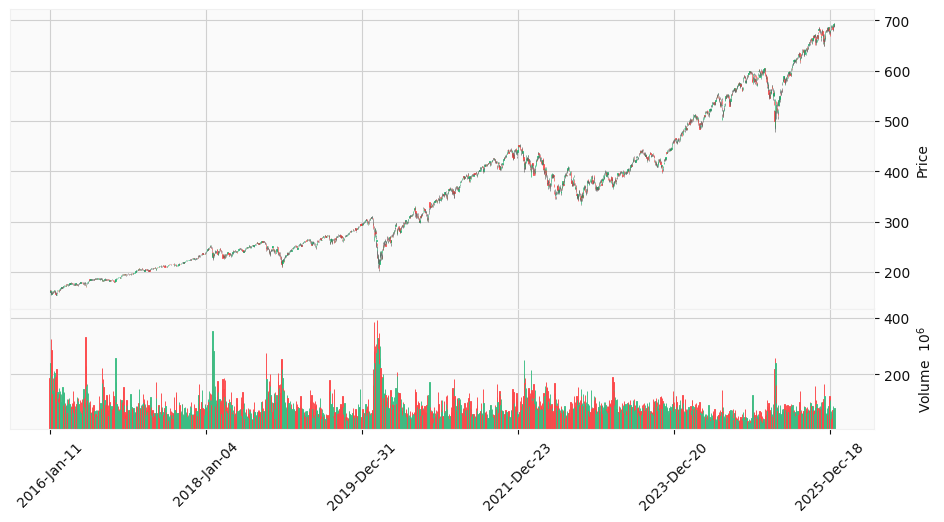

In [107]:
import yfinance as yf
import pandas as pd
import mplfinance as mplf

def fetch_stock_data(ticker_symbol, period='1y', interval='1d'):
    stock = yf.Ticker(ticker_symbol)
    history = stock.history(period=period, interval=interval, auto_adjust=True)
    return history

period = "10y"
interval= "1d"
SnP = fetch_stock_data("SPY", period=period, interval=interval)
Bond= fetch_stock_data("TLT", period=period, interval=interval)
Gold= fetch_stock_data("GLD", period=period, interval=interval)

mplf.plot(SnP,type='candle', volume=True, style='yahoo',figsize=(12, 6))



c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


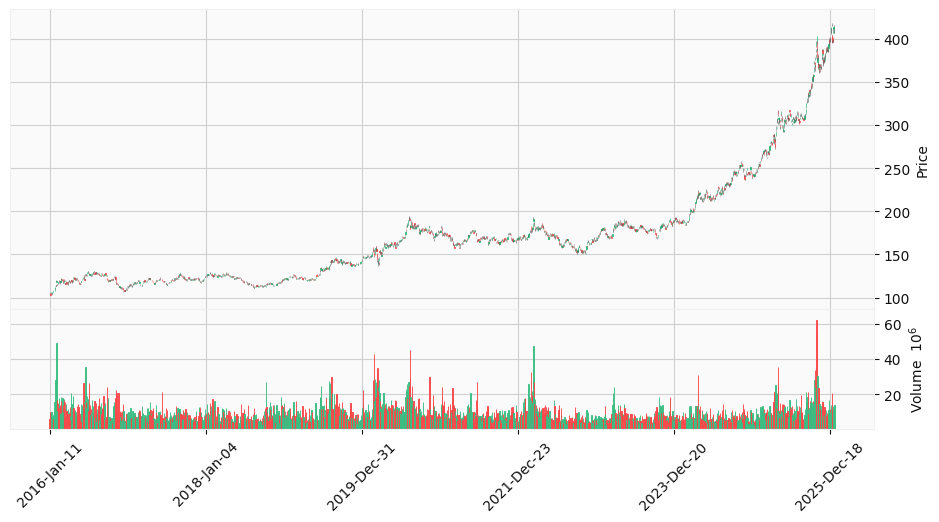

In [108]:
mplf.plot(Gold,type='candle', volume=True, style='yahoo',figsize=(12, 6))


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


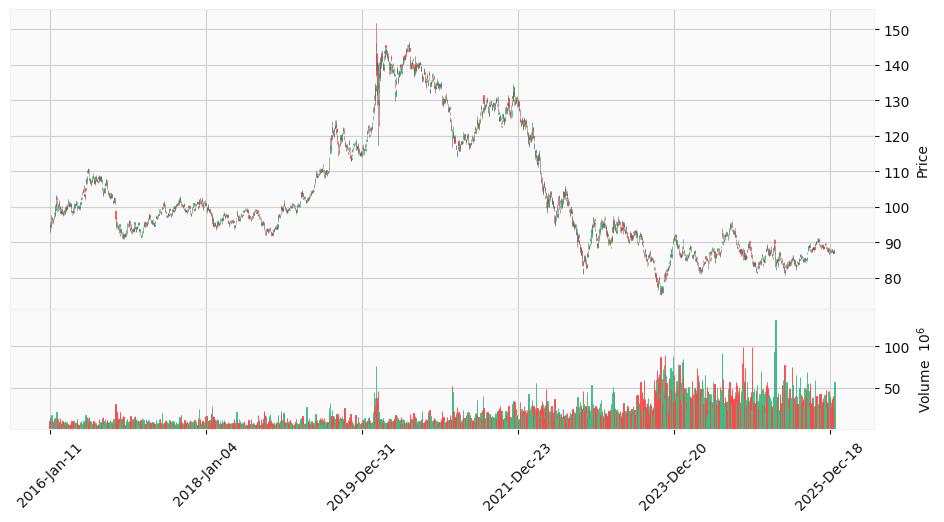

In [109]:
mplf.plot(Bond,type='candle', volume=True, style='yahoo',figsize=(12, 6))


In [110]:
import numpy as np
x = pd.concat(
    {"SnP_Close": SnP["Close"],
    "Bond_Close": Bond["Close"],
    "Gold_Close": Gold["Close"],}
    ,axis=1).copy()


logret = np.log(x[["SnP_Close", "Bond_Close", "Gold_Close"]]).diff()
logret = logret.rename(columns=lambda c: c.replace("_Close", "_LogRet"))
x = pd.concat([x,logret], axis=1).dropna()

weights = np.array([0.6, 0.3, 0.1],dtype=float)

x["portfolio_daily_return"] =  x[["SnP_LogRet","Bond_LogRet","Gold_LogRet"]] @ weights 

x.head(5)

,SnP_Close,Bond_Close,Gold_Close,SnP_LogRet,Bond_LogRet,Gold_LogRet,portfolio_daily_return
Date,,,,,,,
2016-01-12 00:00:00-05:00,164.134293,94.476295,104.209999,0.008036,0.014322,-0.005073,0.008611
2016-01-13 00:00:00-05:00,160.040710,95.407585,104.720001,-0.025257,0.009809,0.004882,-0.011723
2016-01-14 00:00:00-05:00,162.668030,94.514488,103.019997,0.016283,-0.009405,-0.016367,0.005312
2016-01-15 00:00:00-05:00,159.176147,95.987648,104.080002,-0.021700,0.015466,0.010237,-0.007356
2016-01-19 00:00:00-05:00,159.388092,95.689980,103.980003,0.001331,-0.003106,-0.000961,-0.000230


                           portfolio_daily_return  HS_VaR_99
Date                                                        
2026-01-05 00:00:00-05:00                0.008059   0.010149
2026-01-06 00:00:00-05:00                0.004015   0.010149
2026-01-07 00:00:00-05:00               -0.001150   0.010149
2026-01-08 00:00:00-05:00               -0.001018   0.010149
2026-01-09 00:00:00-05:00                0.006662   0.009668


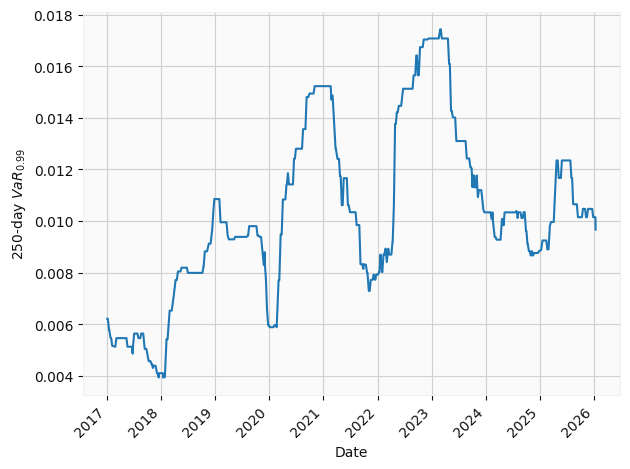

In [111]:
import matplotlib.pyplot as plt
N_window = 250
q_val    = 0.95
alpha    = 1-q_val

historic_VaR = (-x["portfolio_daily_return"]
                .rolling(N_window)
                .quantile(alpha))
x["HS_VaR_99"] = historic_VaR
print(x[["portfolio_daily_return", "HS_VaR_99"]].dropna().tail())
plt.plot(x["HS_VaR_99"])
plt.ylabel(rf"250-day $VaR_{{0.99}}$")
plt.xlabel("Date")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Monte Carlo

                           portfolio_daily_return  HS_VaR_99  MC_VaR_99
Date                                                                   
2026-01-05 00:00:00-05:00                0.008059   0.010149   0.012390
2026-01-06 00:00:00-05:00                0.004015   0.010149   0.012315
2026-01-07 00:00:00-05:00               -0.001150   0.010149   0.012283
2026-01-08 00:00:00-05:00               -0.001018   0.010149   0.012779
2026-01-09 00:00:00-05:00                0.006662   0.009668   0.012357


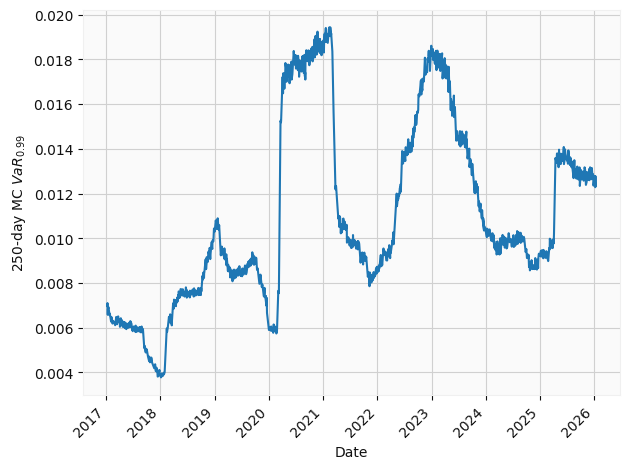

In [112]:
mean =[]
cov  =[]
ret_cols = ["SnP_LogRet", "Bond_LogRet", "Gold_LogRet"]
N_mc = 10_000
mc_var = [np.nan] * N_window
np.random.seed(14502)
Asset_LogRet = x[ret_cols]
for di in range(N_window, x.shape[0]):
    window = Asset_LogRet.iloc[di-N_window:di]

    mu = window.mean().values 
    Sigma=  window.cov().values  

    ret = np.random.multivariate_normal(mu, Sigma, size=N_mc)
    portfolio_ret = ret @ weights 

    mc_var.append(-np.quantile(portfolio_ret, alpha))
x["MC_VaR_99"] = mc_var

print(x[["portfolio_daily_return", "HS_VaR_99","MC_VaR_99"]].dropna().tail())
plt.plot(x["MC_VaR_99"])
plt.ylabel(rf"250-day MC $VaR_{{0.99}}$")
plt.xlabel("Date")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

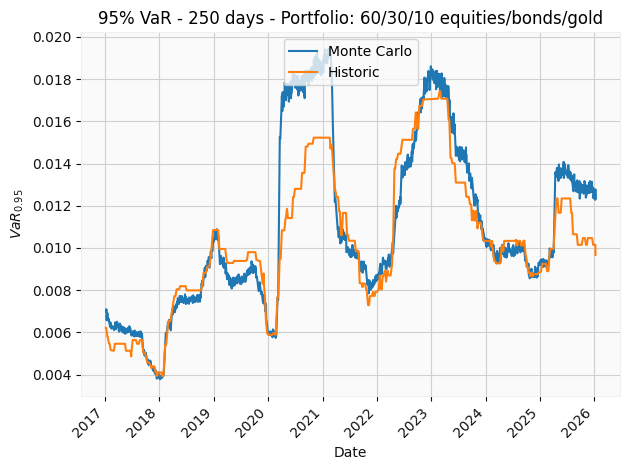

In [113]:
plt.title("95% VaR - 250 days - Portfolio: 60/30/10 equities/bonds/gold")
plt.plot(x["MC_VaR_99"], label="Monte Carlo")
plt.plot(x["HS_VaR_99"], label="Historic")
plt.ylabel(rf"$VaR_{{0.95}}$")
plt.xlabel("Date")
plt.xticks(rotation=45, ha="right")
plt.legend( loc="upper center")
plt.tight_layout()
plt.show()

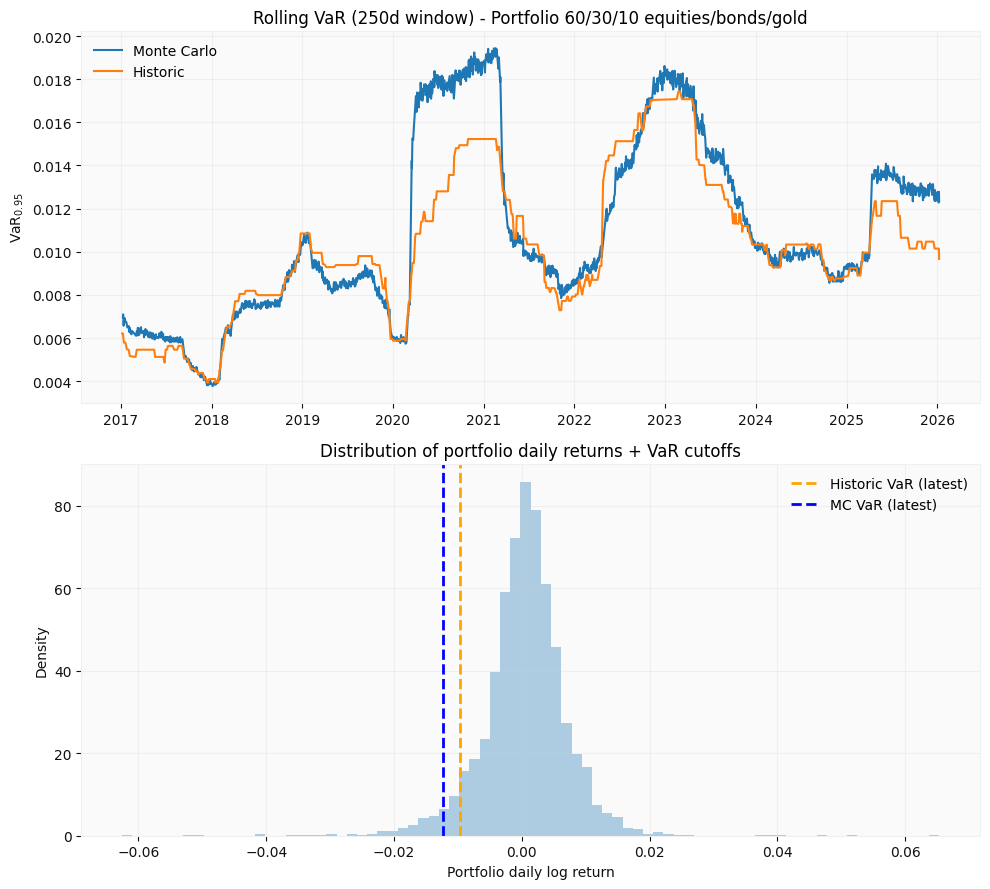

In [114]:
import numpy as np
import matplotlib.pyplot as plt

conf = 0.95
alpha = 1 - conf

ret = x["portfolio_daily_return"].dropna()
hs_var = x["HS_VaR_99"].dropna().iloc[-1]
mc_var = x["MC_VaR_99"].dropna().iloc[-1]

fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# --- Panel 1: VaR time series ---
axes[0].plot(x.index, x["MC_VaR_99"], label="Monte Carlo")
axes[0].plot(x.index, x["HS_VaR_99"], label="Historic")
axes[0].set_title("Rolling VaR (250d window) - Portfolio 60/30/10 equities/bonds/gold")
axes[0].set_ylabel(r"VaR$_{0.95}$")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper left", frameon=False)

# --- Panel 2: returns distribution ---
axes[1].hist(ret, bins=80, density=True, alpha=0.35)
axes[1].axvline(-hs_var, linestyle="--", linewidth=2, label="Historic VaR (latest)", color='orange')
axes[1].axvline(-mc_var, linestyle="--", linewidth=2, label="MC VaR (latest)", color='blue')
axes[1].set_title("Distribution of portfolio daily returns + VaR cutoffs")
axes[1].set_xlabel("Portfolio daily log return")
axes[1].set_ylabel("Density")
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False)

#plt.xticks(rotation=45, ha="right")
fig.tight_layout()

plt.savefig("VaR95_250d_6SPY_3TLT_1GOLD.png",dpi=300)
plt.show()


In [115]:
weights_dict = {
    "60_30_10": np.array([0.60, 0.30, 0.10]),
    "80_15_05": np.array([0.80, 0.15, 0.05]),
    "40_40_20": np.array([0.40, 0.40, 0.20]),
    "20_70_10": np.array([0.20, 0.70, 0.10]),
}

ret_cols = ["SnP_LogRet", "Bond_LogRet", "Gold_LogRet"]
R = x[ret_cols]

N_window = 250
conf = 0.95
alpha = 1 - conf
Nsim = 10_000

# sanity checks
assert R.shape[1] == 3

for name, w in weights_dict.items():
    w = np.array(w, dtype=float)
    assert w.shape == (3,)
    assert np.isclose(w.sum(), 1.0), f"Weights {name} do not sum to 1!"

    # ---- Portfolio daily return series
    port_ret_col = f"portfolio_ret_{name}"
    x[port_ret_col] = R @ w

    # ---- Historical VaR (rolling quantile)
    hs_col = f"HS_VaR_{int(conf*100)}_{name}"
    x[hs_col] = (-x[port_ret_col].rolling(N_window).quantile(alpha))

    # ---- Monte Carlo VaR
    mc_col = f"MC_VaR_{int(conf*100)}_{name}"
    mc_var = [np.nan] * N_window

    for di in range(N_window, len(x)):
        window = R.iloc[di-N_window:di]
        mu = window.mean().values
        Sigma = window.cov().values

        sims = np.random.multivariate_normal(mu, Sigma, size=Nsim)
        port_sims = sims @ w
        mc_var.append(-np.quantile(port_sims, alpha))

    x[mc_col] = mc_var
    

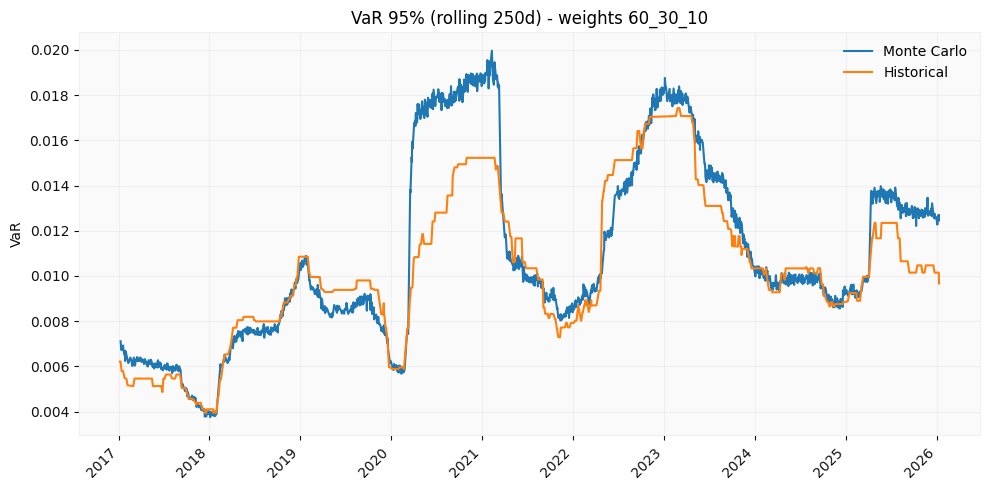

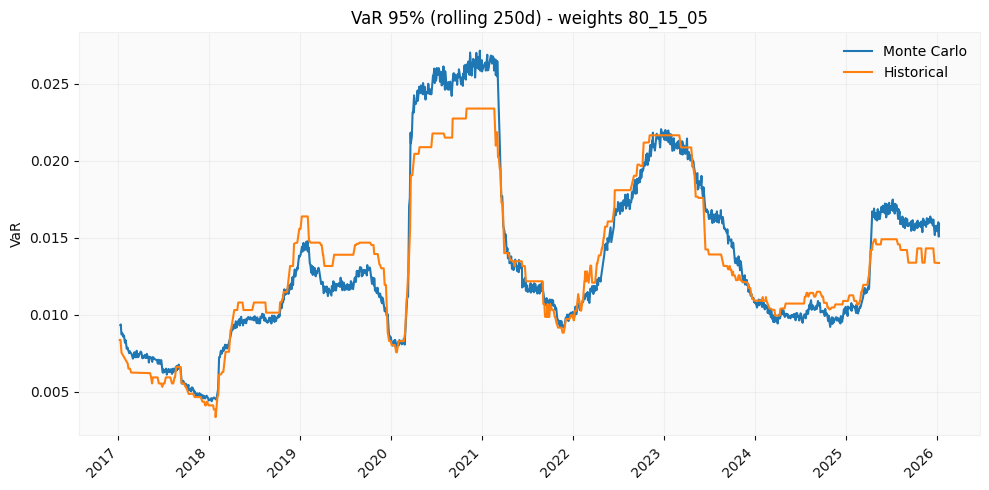

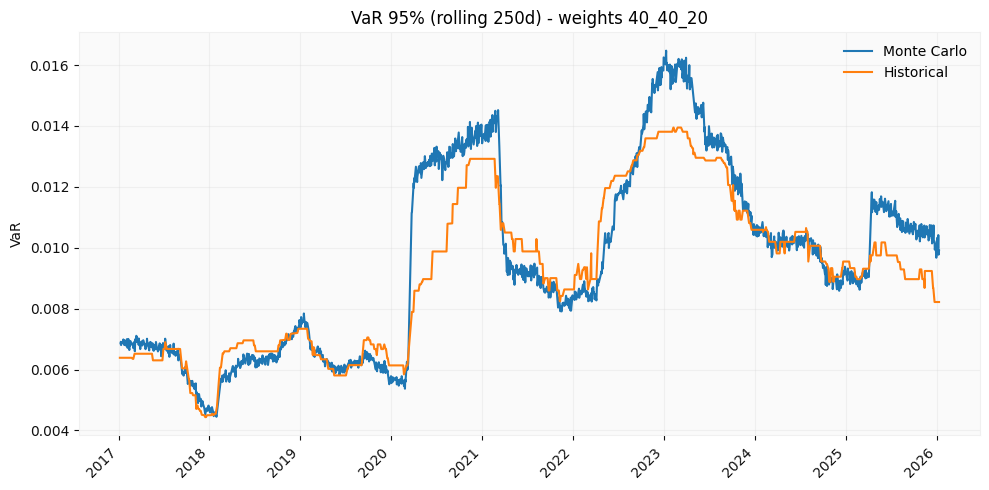

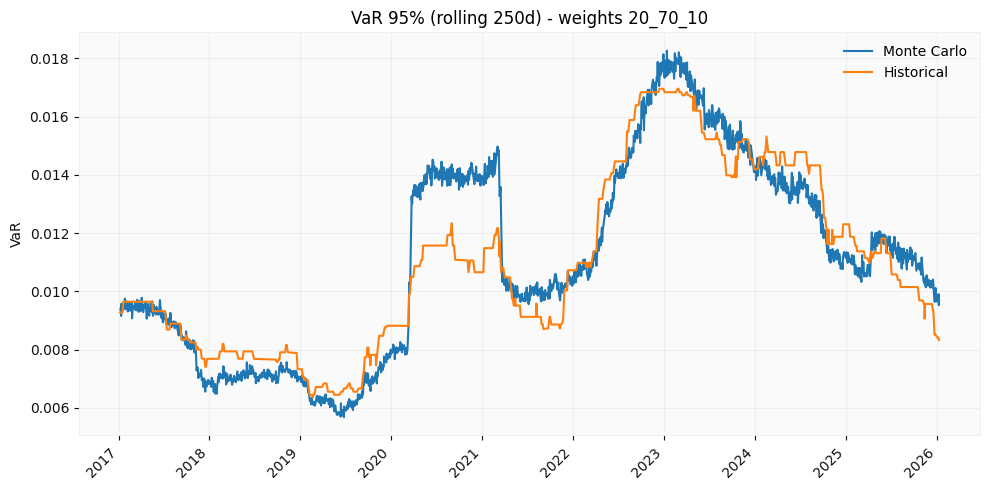

In [116]:
name = "60_30_10"  # pick any key in weights_dict
hs_col = f"HS_VaR_95_{name}"
mc_col = f"MC_VaR_95_{name}"

plt.figure(figsize=(10,5))
plt.plot(x.index, x[mc_col], label="Monte Carlo")
plt.plot(x.index, x[hs_col], label="Historical")
plt.title(f"VaR 95% (rolling {N_window}d) - weights {name}")
plt.ylabel("VaR")
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

name = "80_15_05"  # pick any key in weights_dict
hs_col = f"HS_VaR_95_{name}"
mc_col = f"MC_VaR_95_{name}"

plt.figure(figsize=(10,5))
plt.plot(x.index, x[mc_col], label="Monte Carlo")
plt.plot(x.index, x[hs_col], label="Historical")
plt.title(f"VaR 95% (rolling {N_window}d) - weights {name}")
plt.ylabel("VaR")
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

name = "40_40_20"  # pick any key in weights_dict
hs_col = f"HS_VaR_95_{name}"
mc_col = f"MC_VaR_95_{name}"

plt.figure(figsize=(10,5))
plt.plot(x.index, x[mc_col], label="Monte Carlo")
plt.plot(x.index, x[hs_col], label="Historical")
plt.title(f"VaR 95% (rolling {N_window}d) - weights {name}")
plt.ylabel("VaR")
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

name = "20_70_10"  # pick any key in weights_dict
hs_col = f"HS_VaR_95_{name}"
mc_col = f"MC_VaR_95_{name}"

plt.figure(figsize=(10,5))
plt.plot(x.index, x[mc_col], label="Monte Carlo")
plt.plot(x.index, x[hs_col], label="Historical")
plt.title(f"VaR 95% (rolling {N_window}d) - weights {name}")
plt.ylabel("VaR")
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [117]:
rows = []
for name in weights_dict.keys():
    hs_col = f"HS_VaR_95_{name}"
    mc_col = f"MC_VaR_95_{name}"

    hs_latest = x[hs_col].dropna().iloc[-1]
    mc_latest = x[mc_col].dropna().iloc[-1]

    rows.append({
        "weights": name,
        "HS_VaR_95_latest": hs_latest,
        "MC_VaR_95_latest": mc_latest,
        "MC_minus_HS": mc_latest - hs_latest
    })

summary = pd.DataFrame(rows).sort_values("MC_minus_HS", ascending=False)
summary

,weights,HS_VaR_95_latest,MC_VaR_95_latest,MC_minus_HS
0,60_30_10,0.009668,0.012675,0.003007
1,80_15_05,0.013369,0.015880,0.002511
2,40_40_20,0.008218,0.009907,0.001689
3,20_70_10,0.008333,0.009668,0.001335


In [118]:
conf = 0.95

rows = []
for name in weights_dict.keys():
    hs_col = f"HS_VaR_{int(conf*100)}_{name}"
    mc_col = f"MC_VaR_{int(conf*100)}_{name}"

    tmp = x[[hs_col, mc_col]].dropna()
    d = tmp[hs_col] - tmp[mc_col]              # daily difference

    rows.append({
        "weights": name,
        "mean_diff": d.mean(),
        "mean_abs_diff": d.abs().mean(),
        "rmse": np.sqrt((d**2).mean()),
        "mean_rel_diff": (d / tmp[mc_col]).mean(),
    })

summary = pd.DataFrame(rows).sort_values("rmse", ascending=False)
summary

,weights,mean_diff,mean_abs_diff,rmse,mean_rel_diff
0,60_30_10,-0.000655,0.001169,0.001784,-0.038894
1,80_15_05,-0.000261,0.001264,0.001610,-0.006524
2,40_40_20,-0.000368,0.000803,0.001151,-0.021521
3,20_70_10,-0.000139,0.000876,0.001140,0.001941


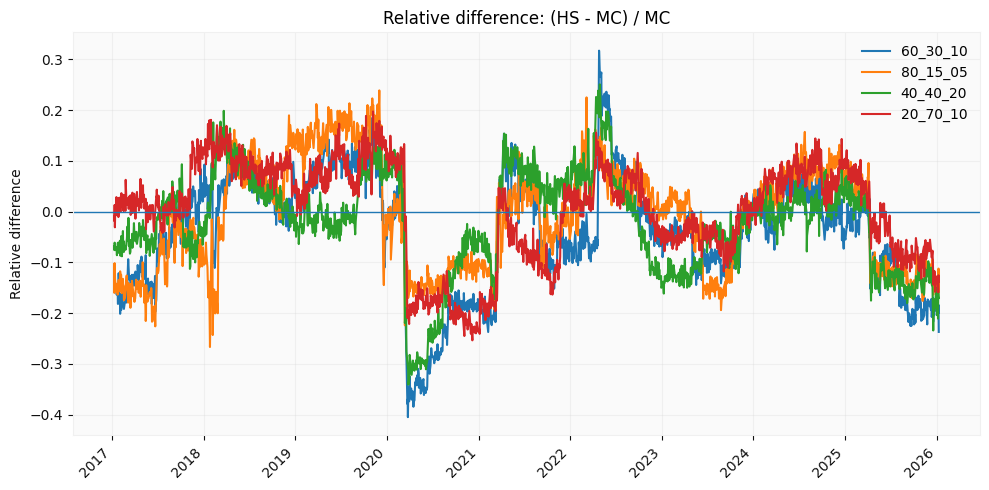

In [119]:

conf = 0.95
names = ["60_30_10", "80_15_05", "40_40_20", "20_70_10"]

plt.figure(figsize=(10,5))

for name in names:
    hs_col = f"HS_VaR_{int(conf*100)}_{name}"
    mc_col = f"MC_VaR_{int(conf*100)}_{name}"

    tmp = x[[hs_col, mc_col]].dropna()
    rel_diff = (tmp[hs_col] - tmp[mc_col]) / tmp[mc_col]

    plt.plot(rel_diff.index, rel_diff, label=name)

plt.axhline(0, linewidth=1)
plt.title("Relative difference: (HS - MC) / MC")
plt.ylabel("Relative difference")
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [120]:
threshold = 0.05  # 5%

for name in names:
    hs_col = f"HS_VaR_{int(conf*100)}_{name}"
    mc_col = f"MC_VaR_{int(conf*100)}_{name}"
    tmp = x[[hs_col, mc_col]].dropna()

    rel_diff = (tmp[hs_col] - tmp[mc_col]) / tmp[mc_col]
    frac = (rel_diff.abs() > threshold).mean()

    print(name, frac)

60_30_10 0.6492932862190812
80_15_05 0.7058303886925795
40_40_20 0.5746466431095406
20_70_10 0.6523851590106007
